# DATA VORTEX 2026 - ROUND 2
## NLP Semantic Recovery

**Participant:** YOGESH R MEHTA  
**Register Number:** RA2411003010776

This notebook is configured for the supplied Social NLP Training Dataset.

**Dataset path:**
`E:\Desktop\Projects\DATA VORTEX\Labeled_Social_NLP_Training_Data.csv`

**Dataset columns:**
- `text_id`
- `post_text`
- `sentiment_label`
- `topic_category`

The notebook trains two NLP classification tasks:
1. Sentiment classification
2. Topic classification

It compares multiple TF-IDF based models, evaluates them using accuracy, precision, recall and F1 score, performs confusion matrix analysis, and saves the trained models.

In [1]:
# Install required packages if needed
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Dataset

The notebook uses the exact Windows path supplied for the project.

In [3]:
DATASET_PATH = r"E:\Desktop\Projects\DATA VORTEX\Labeled_Social_NLP_Training_Data.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}"
    )

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully")
print("Path:", DATASET_PATH)
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Path: E:\Desktop\Projects\DATA VORTEX\Labeled_Social_NLP_Training_Data.csv
Shape: (9000, 4)


,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@...,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better t...,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala a...,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to...,Negative,Community_Discussion


## 2. Dataset Inspection

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

Columns:
['text_id', 'post_text', 'sentiment_label', 'topic_category']

Data types:


text_id            object
post_text          object
sentiment_label    object
topic_category     object
dtype: object


Missing values:


text_id            0
post_text          0
sentiment_label    0
topic_category     0
dtype: int64


Duplicate rows: 0

Dataset shape: (9000, 4)


In [5]:
print("Unique sentiment labels:")
print(df["sentiment_label"].value_counts())

print("\nUnique topic categories:")
print(df["topic_category"].value_counts())

print("\nNumber of sentiment classes:", df["sentiment_label"].nunique())
print("Number of topic classes:", df["topic_category"].nunique())

Unique sentiment labels:
sentiment_label
Negative    3000
Positive    3000
Neutral     3000
Name: count, dtype: int64

Unique topic categories:
topic_category
Community_Discussion    7752
Technical_Issues         815
Feature_Feedback         297
Account_Security         136
Name: count, dtype: int64

Number of sentiment classes: 3
Number of topic classes: 4


## 3. Data Cleaning and NLP Preprocessing

In [6]:
# Keep the relevant columns
data = df[["text_id", "post_text", "sentiment_label", "topic_category"]].copy()

# Remove rows missing required fields
data = data.dropna(
    subset=["post_text", "sentiment_label", "topic_category"]
)

# Convert text and labels to strings
data["post_text"] = data["post_text"].astype(str)
data["sentiment_label"] = data["sentiment_label"].astype(str)
data["topic_category"] = data["topic_category"].astype(str)

# Remove empty posts
data = data[data["post_text"].str.strip().str.len() > 0]

# Remove exact duplicate records
data = data.drop_duplicates()

data = data.reset_index(drop=True)

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape :", data.shape)

display(data.head())

Original dataset shape: (9000, 4)
Cleaned dataset shape : (9000, 4)


,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@...,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better t...,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala a...,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to...,Negative,Community_Discussion


In [7]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove user mentions
    text = re.sub(r"@\w+", " ", text)

    # Convert hashtags to words
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep letters, numbers and whitespace
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


data["clean_text"] = data["post_text"].apply(clean_text)

display(
    data[["post_text", "clean_text", "sentiment_label", "topic_category"]].head(10)
)

,post_text,clean_text,sentiment_label,topic_category
0,some1 come wait in line with me Thursday at 3@...,some1 come wait in line with me thursday at 3 ...,Negative,Community_Discussion
1,Mancity strikers Aguero and Dzeko you better t...,mancity strikers aguero and dzeko you better t...,Positive,Community_Discussion
2,Would you like to join us at our annual gala a...,would you like to join us at our annual gala a...,Positive,Community_Discussion
3,"""Sicily may form grand coalition, Italian UDC ...",sicily may form grand coalition italian udc pa...,Neutral,Community_Discussion
4,@user @user If the comment was in reference to...,if the comment was in reference to the charlie...,Negative,Community_Discussion
5,@user @user aaaah. Nokia used to make the Best...,aaaah nokia used to make the best phone camera...,Negative,Community_Discussion
6,Curtis Painter was asked in interviews today i...,curtis painter was asked in interviews today i...,Neutral,Account_Security
7,"""When gaza march out pon the battlefield it's ...",when gaza march out pon the battlefield it s a...,Negative,Community_Discussion
8,"""WLS Quick Look """" Caitlyn Jenner - 1st Public...",wls quick look caitlyn jenner 1st public reuni...,Neutral,Feature_Feedback
9,"""1st game played under Solar Powered floodligh...",1st game played under solar powered floodlight...,Neutral,Technical_Issues


## 4. Exploratory Data Analysis

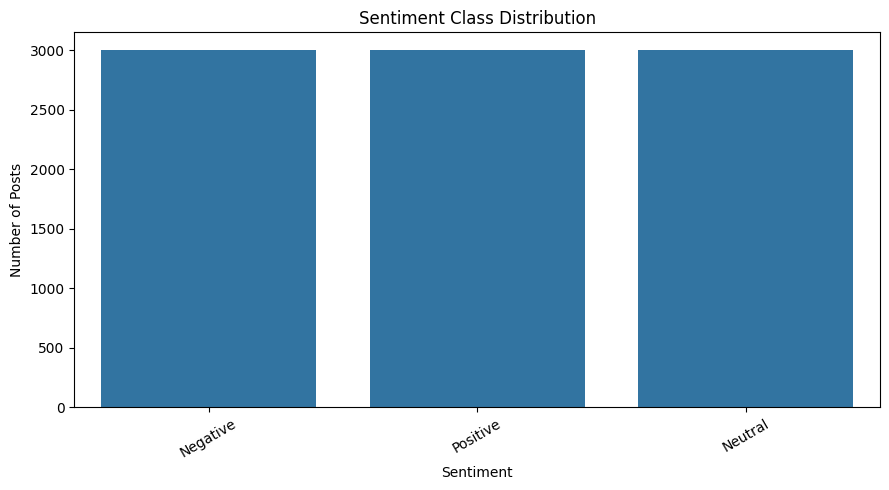

In [8]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=data,
    x="sentiment_label",
    order=data["sentiment_label"].value_counts().index
)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

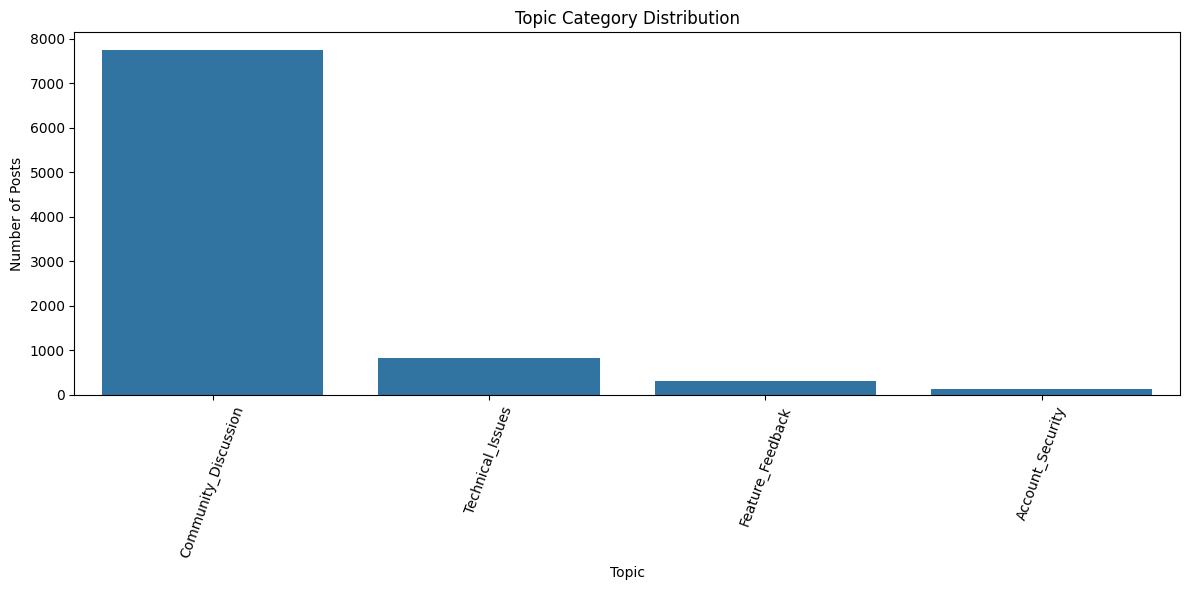

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=data,
    x="topic_category",
    order=data["topic_category"].value_counts().index
)
plt.title("Topic Category Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Posts")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [10]:
print("Sentiment percentages:")
display(
    data["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
)

print("Topic percentages:")
display(
    data["topic_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
)

Sentiment percentages:


sentiment_label
Negative    33.33
Positive    33.33
Neutral     33.33
Name: Percentage, dtype: float64

Topic percentages:


topic_category
Community_Discussion    86.13
Technical_Issues         9.06
Feature_Feedback         3.30
Account_Security         1.51
Name: Percentage, dtype: float64

# PART A - SENTIMENT CLASSIFICATION

In [11]:
X = data["clean_text"]
y_sentiment = data["sentiment_label"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_sentiment,
    test_size=0.20,
    random_state=42,
    stratify=y_sentiment
)

print("Sentiment training samples:", len(X_train_s))
print("Sentiment testing samples :", len(X_test_s))
print("Sentiment classes:", sorted(y_sentiment.unique()))

Sentiment training samples: 7200
Sentiment testing samples : 1800
Sentiment classes: ['Negative', 'Neutral', 'Positive']


## 5. Sentiment Model 1 - Word TF-IDF + Logistic Regression

In [12]:
sent_logistic = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

sent_logistic.fit(X_train_s, y_train_s)
pred_sent_logistic = sent_logistic.predict(X_test_s)

sent_logistic_metrics = {
    "Accuracy": accuracy_score(y_test_s, pred_sent_logistic),
    "Precision": precision_score(y_test_s, pred_sent_logistic, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_s, pred_sent_logistic, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_s, pred_sent_logistic, average="weighted", zero_division=0)
}

print("Sentiment Logistic Regression")
for k, v in sent_logistic_metrics.items():
    print(f"{k}: {v:.4f}")

Sentiment Logistic Regression
Accuracy: 0.6456
Precision: 0.6452
Recall: 0.6456
F1 Score: 0.6454


## 6. Sentiment Model 2 - Word TF-IDF + Linear SVM

In [13]:
sent_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

sent_svm.fit(X_train_s, y_train_s)
pred_sent_svm = sent_svm.predict(X_test_s)

sent_svm_metrics = {
    "Accuracy": accuracy_score(y_test_s, pred_sent_svm),
    "Precision": precision_score(y_test_s, pred_sent_svm, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_s, pred_sent_svm, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_s, pred_sent_svm, average="weighted", zero_division=0)
}

print("Sentiment Linear SVM")
for k, v in sent_svm_metrics.items():
    print(f"{k}: {v:.4f}")

Sentiment Linear SVM
Accuracy: 0.6522
Precision: 0.6527
Recall: 0.6522
F1 Score: 0.6524


## 7. Sentiment Model 3 - Word TF-IDF + Complement Naive Bayes

In [14]:
sent_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", ComplementNB())
])

sent_nb.fit(X_train_s, y_train_s)
pred_sent_nb = sent_nb.predict(X_test_s)

sent_nb_metrics = {
    "Accuracy": accuracy_score(y_test_s, pred_sent_nb),
    "Precision": precision_score(y_test_s, pred_sent_nb, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_s, pred_sent_nb, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_s, pred_sent_nb, average="weighted", zero_division=0)
}

print("Sentiment Complement Naive Bayes")
for k, v in sent_nb_metrics.items():
    print(f"{k}: {v:.4f}")

Sentiment Complement Naive Bayes
Accuracy: 0.6389
Precision: 0.6366
Recall: 0.6389
F1 Score: 0.6355


## 8. Sentiment Model 4 - Character TF-IDF + Linear SVM

In [15]:
sent_char_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        max_features=150000,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

sent_char_svm.fit(X_train_s, y_train_s)
pred_sent_char = sent_char_svm.predict(X_test_s)

sent_char_metrics = {
    "Accuracy": accuracy_score(y_test_s, pred_sent_char),
    "Precision": precision_score(y_test_s, pred_sent_char, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_s, pred_sent_char, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_s, pred_sent_char, average="weighted", zero_division=0)
}

print("Sentiment Character TF-IDF + SVM")
for k, v in sent_char_metrics.items():
    print(f"{k}: {v:.4f}")

Sentiment Character TF-IDF + SVM
Accuracy: 0.6472
Precision: 0.6464
Recall: 0.6472
F1 Score: 0.6468


## 9. Sentiment Model Comparison

In [16]:
sentiment_results = pd.DataFrame([
    {"Model": "Word TF-IDF + Logistic Regression", **sent_logistic_metrics},
    {"Model": "Word TF-IDF + Linear SVM", **sent_svm_metrics},
    {"Model": "Word TF-IDF + Complement NB", **sent_nb_metrics},
    {"Model": "Character TF-IDF + Linear SVM", **sent_char_metrics}
])

sentiment_results = sentiment_results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(sentiment_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Word TF-IDF + Linear SVM,0.652222,0.652721,0.652222,0.652432
1,Character TF-IDF + Linear SVM,0.647222,0.646398,0.647222,0.646755
2,Word TF-IDF + Logistic Regression,0.645556,0.645242,0.645556,0.645359
3,Word TF-IDF + Complement NB,0.638889,0.636624,0.638889,0.635513


In [17]:
sentiment_models = {
    "Word TF-IDF + Logistic Regression": sent_logistic,
    "Word TF-IDF + Linear SVM": sent_svm,
    "Word TF-IDF + Complement NB": sent_nb,
    "Character TF-IDF + Linear SVM": sent_char_svm
}

sentiment_f1 = {
    row["Model"]: row["F1 Score"]
    for _, row in sentiment_results.iterrows()
}

BEST_SENTIMENT_MODEL_NAME = max(sentiment_f1, key=sentiment_f1.get)
BEST_SENTIMENT_MODEL = sentiment_models[BEST_SENTIMENT_MODEL_NAME]

print("Selected sentiment model:")
print(BEST_SENTIMENT_MODEL_NAME)
print("Weighted F1:", f"{sentiment_f1[BEST_SENTIMENT_MODEL_NAME]:.4f}")

Selected sentiment model:
Word TF-IDF + Linear SVM
Weighted F1: 0.6524


Best Sentiment Model Classification Report
              precision    recall  f1-score   support

    Negative       0.69      0.68      0.69       600
     Neutral       0.60      0.60      0.60       600
    Positive       0.67      0.67      0.67       600

    accuracy                           0.65      1800
   macro avg       0.65      0.65      0.65      1800
weighted avg       0.65      0.65      0.65      1800



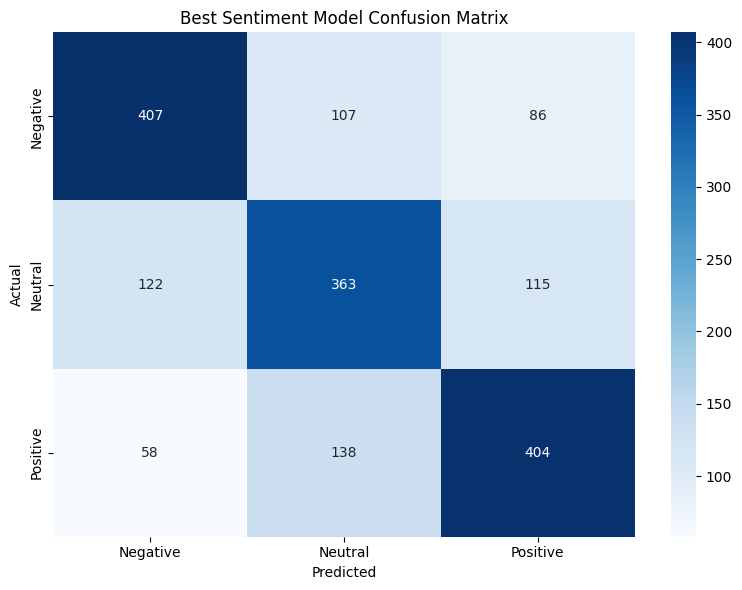

In [18]:
best_sentiment_predictions = BEST_SENTIMENT_MODEL.predict(X_test_s)

print("Best Sentiment Model Classification Report")
print("=" * 70)
print(
    classification_report(
        y_test_s,
        best_sentiment_predictions,
        zero_division=0
    )
)

sent_labels = sorted(y_sentiment.unique())
sent_cm = confusion_matrix(
    y_test_s,
    best_sentiment_predictions,
    labels=sent_labels
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    sent_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sent_labels,
    yticklabels=sent_labels
)
plt.title("Best Sentiment Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# PART B - TOPIC CLASSIFICATION

In [19]:
y_topic = data["topic_category"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X,
    y_topic,
    test_size=0.20,
    random_state=42,
    stratify=y_topic
)

print("Topic training samples:", len(X_train_t))
print("Topic testing samples :", len(X_test_t))
print("Number of topic classes:", y_topic.nunique())

Topic training samples: 7200
Topic testing samples : 1800
Number of topic classes: 4


## 10. Topic Model 1 - Word TF-IDF + Logistic Regression

In [20]:
topic_logistic = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LogisticRegression(
        max_iter=2500,
        class_weight="balanced"
    ))
])

topic_logistic.fit(X_train_t, y_train_t)
pred_topic_logistic = topic_logistic.predict(X_test_t)

topic_logistic_metrics = {
    "Accuracy": accuracy_score(y_test_t, pred_topic_logistic),
    "Precision": precision_score(y_test_t, pred_topic_logistic, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_t, pred_topic_logistic, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_t, pred_topic_logistic, average="weighted", zero_division=0)
}

print("Topic Logistic Regression")
for k, v in topic_logistic_metrics.items():
    print(f"{k}: {v:.4f}")

Topic Logistic Regression
Accuracy: 0.9400
Precision: 0.9367
Recall: 0.9400
F1 Score: 0.9362


## 11. Topic Model 2 - Word TF-IDF + Linear SVM

In [21]:
topic_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

topic_svm.fit(X_train_t, y_train_t)
pred_topic_svm = topic_svm.predict(X_test_t)

topic_svm_metrics = {
    "Accuracy": accuracy_score(y_test_t, pred_topic_svm),
    "Precision": precision_score(y_test_t, pred_topic_svm, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_t, pred_topic_svm, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_t, pred_topic_svm, average="weighted", zero_division=0)
}

print("Topic Linear SVM")
for k, v in topic_svm_metrics.items():
    print(f"{k}: {v:.4f}")

Topic Linear SVM
Accuracy: 0.9500
Precision: 0.9506
Recall: 0.9500
F1 Score: 0.9444


## 12. Topic Model 3 - Word TF-IDF + Complement Naive Bayes

In [22]:
topic_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )),
    ("classifier", ComplementNB())
])

topic_nb.fit(X_train_t, y_train_t)
pred_topic_nb = topic_nb.predict(X_test_t)

topic_nb_metrics = {
    "Accuracy": accuracy_score(y_test_t, pred_topic_nb),
    "Precision": precision_score(y_test_t, pred_topic_nb, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_t, pred_topic_nb, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_t, pred_topic_nb, average="weighted", zero_division=0)
}

print("Topic Complement Naive Bayes")
for k, v in topic_nb_metrics.items():
    print(f"{k}: {v:.4f}")

Topic Complement Naive Bayes
Accuracy: 0.8822
Precision: 0.8870
Recall: 0.8822
F1 Score: 0.8437


## 13. Topic Model 4 - Character TF-IDF + Linear SVM

In [23]:
topic_char_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        max_features=150000,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

topic_char_svm.fit(X_train_t, y_train_t)
pred_topic_char = topic_char_svm.predict(X_test_t)

topic_char_metrics = {
    "Accuracy": accuracy_score(y_test_t, pred_topic_char),
    "Precision": precision_score(y_test_t, pred_topic_char, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_t, pred_topic_char, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test_t, pred_topic_char, average="weighted", zero_division=0)
}

print("Topic Character TF-IDF + SVM")
for k, v in topic_char_metrics.items():
    print(f"{k}: {v:.4f}")

Topic Character TF-IDF + SVM
Accuracy: 0.9689
Precision: 0.9690
Recall: 0.9689
F1 Score: 0.9656


## 14. Topic Model Comparison

In [24]:
topic_results = pd.DataFrame([
    {"Model": "Word TF-IDF + Logistic Regression", **topic_logistic_metrics},
    {"Model": "Word TF-IDF + Linear SVM", **topic_svm_metrics},
    {"Model": "Word TF-IDF + Complement NB", **topic_nb_metrics},
    {"Model": "Character TF-IDF + Linear SVM", **topic_char_metrics}
])

topic_results = topic_results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(topic_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Character TF-IDF + Linear SVM,0.968889,0.969016,0.968889,0.965607
1,Word TF-IDF + Linear SVM,0.950000,0.950603,0.950000,0.944385
2,Word TF-IDF + Logistic Regression,0.940000,0.936744,0.940000,0.936250
3,Word TF-IDF + Complement NB,0.882222,0.887042,0.882222,0.843699


In [25]:
topic_models = {
    "Word TF-IDF + Logistic Regression": topic_logistic,
    "Word TF-IDF + Linear SVM": topic_svm,
    "Word TF-IDF + Complement NB": topic_nb,
    "Character TF-IDF + Linear SVM": topic_char_svm
}

topic_f1 = {
    row["Model"]: row["F1 Score"]
    for _, row in topic_results.iterrows()
}

BEST_TOPIC_MODEL_NAME = max(topic_f1, key=topic_f1.get)
BEST_TOPIC_MODEL = topic_models[BEST_TOPIC_MODEL_NAME]

print("Selected topic model:")
print(BEST_TOPIC_MODEL_NAME)
print("Weighted F1:", f"{topic_f1[BEST_TOPIC_MODEL_NAME]:.4f}")

Selected topic model:
Character TF-IDF + Linear SVM
Weighted F1: 0.9656


Best Topic Model Classification Report
                      precision    recall  f1-score   support

    Account_Security       0.93      0.52      0.67        27
Community_Discussion       0.97      1.00      0.98      1551
    Feature_Feedback       0.97      0.54      0.70        59
    Technical_Issues       1.00      0.90      0.95       163

            accuracy                           0.97      1800
           macro avg       0.97      0.74      0.82      1800
        weighted avg       0.97      0.97      0.97      1800



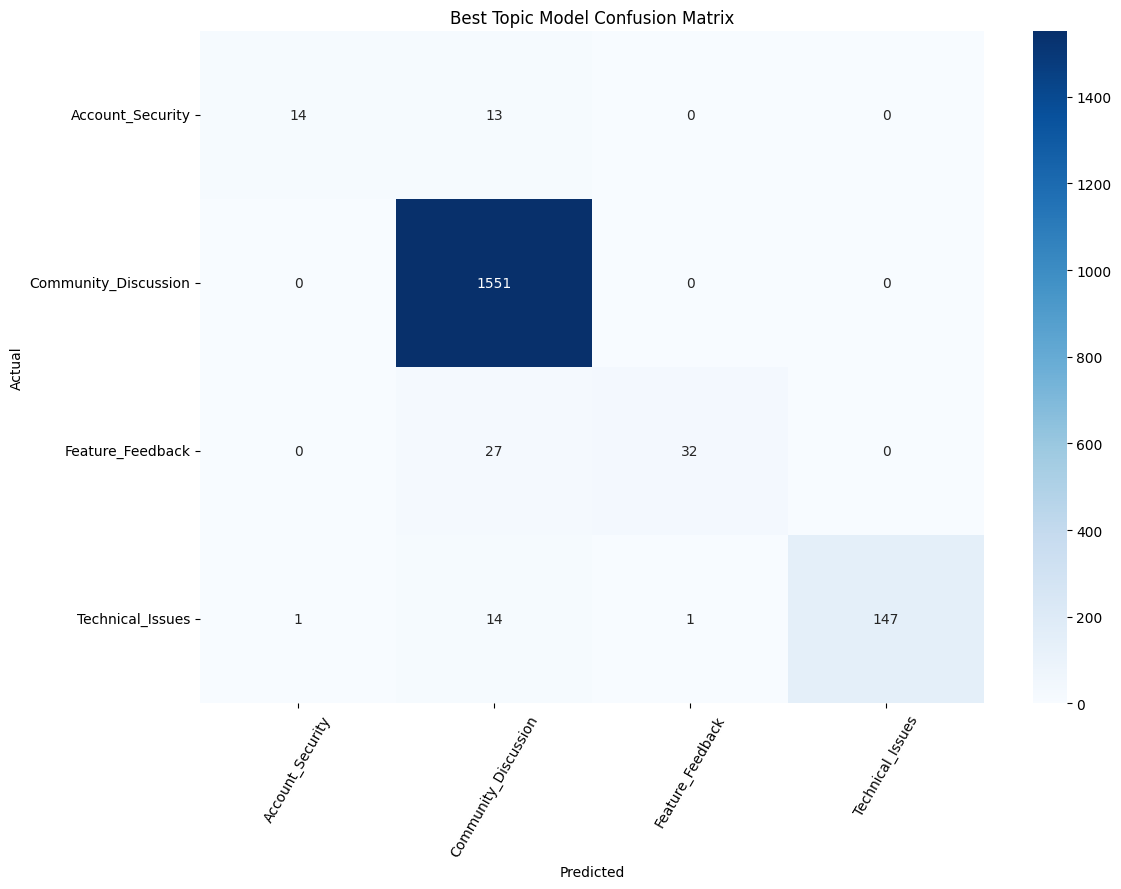

In [26]:
best_topic_predictions = BEST_TOPIC_MODEL.predict(X_test_t)

print("Best Topic Model Classification Report")
print("=" * 70)
print(
    classification_report(
        y_test_t,
        best_topic_predictions,
        zero_division=0
    )
)

topic_labels = sorted(y_topic.unique())
topic_cm = confusion_matrix(
    y_test_t,
    best_topic_predictions,
    labels=topic_labels
)

plt.figure(figsize=(12, 9))
sns.heatmap(
    topic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=topic_labels,
    yticklabels=topic_labels
)
plt.title("Best Topic Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# PART C - ERROR ANALYSIS

In [27]:
sentiment_errors = pd.DataFrame({
    "Text": X_test_s.values,
    "Actual": y_test_s.values,
    "Predicted": best_sentiment_predictions
})

sentiment_errors = sentiment_errors[
    sentiment_errors["Actual"] != sentiment_errors["Predicted"]
]

print("Sentiment errors:", len(sentiment_errors))
display(sentiment_errors.head(20))

Sentiment errors: 626


,Text,Actual,Predicted
1,i still think it was fake i always thought nic...,Negative,Neutral
2,john cena throwing jon stewart at the wwe is p...,Positive,Neutral
3,1st this writer implies i copied kpop now lect...,Neutral,Negative
4,jeb bush dug himself a deep hole with his act ...,Negative,Positive
7,hard to be excited about eric church at wefest...,Negative,Positive
10,august 29 2015 video what sarah palin and dona...,Positive,Negative
12,floyd mayweather vs andre berto sept 12th i m ...,Neutral,Positive
23,i miss old school dashboard confessional takin...,Negative,Positive
25,yeah keeps my mind off of not having any hedle...,Neutral,Negative
30,sunrise rahul gandhi can you see sunlight stud...,Neutral,Negative


In [28]:
topic_errors = pd.DataFrame({
    "Text": X_test_t.values,
    "Actual": y_test_t.values,
    "Predicted": best_topic_predictions
})

topic_errors = topic_errors[
    topic_errors["Actual"] != topic_errors["Predicted"]
]

print("Topic errors:", len(topic_errors))
display(topic_errors.head(20))

Topic errors: 56


,Text,Actual,Predicted
4,my passion nhk announces hosts for the 63rd an...,Feature_Feedback,Community_Discussion
11,in today s guide i faff around the set of tfi ...,Feature_Feedback,Community_Discussion
43,i m going to claytons tomorrow morning but i m...,Feature_Feedback,Community_Discussion
80,issuing notices to channels fr cntent arnd yak...,Feature_Feedback,Community_Discussion
85,inmarsat u2019s swiftbroadband soars to new he...,Account_Security,Community_Discussion
141,if israel withdrew from west bank tomorrow it ...,Account_Security,Community_Discussion
146,tony blair sees his millions as modest yes he ...,Feature_Feedback,Community_Discussion
169,who will we be seeing on friday at the sheepan...,Technical_Issues,Community_Discussion
270,bake off strictly big brother x factor it s th...,Feature_Feedback,Community_Discussion
322,i hope you get kidnapped tomorrow and shipped ...,Technical_Issues,Community_Discussion


# PART D - FINAL SUMMARY

In [29]:
final_summary = pd.DataFrame([
    {
        "Task": "Sentiment Classification",
        "Best Model": BEST_SENTIMENT_MODEL_NAME,
        "Accuracy": accuracy_score(y_test_s, best_sentiment_predictions),
        "Precision": precision_score(y_test_s, best_sentiment_predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_s, best_sentiment_predictions, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test_s, best_sentiment_predictions, average="weighted", zero_division=0)
    },
    {
        "Task": "Topic Classification",
        "Best Model": BEST_TOPIC_MODEL_NAME,
        "Accuracy": accuracy_score(y_test_t, best_topic_predictions),
        "Precision": precision_score(y_test_t, best_topic_predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_t, best_topic_predictions, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test_t, best_topic_predictions, average="weighted", zero_division=0)
    }
])

display(final_summary)

,Task,Best Model,Accuracy,Precision,Recall,F1 Score
0,Sentiment Classification,Word TF-IDF + Linear SVM,0.652222,0.652721,0.652222,0.652432
1,Topic Classification,Character TF-IDF + Linear SVM,0.968889,0.969016,0.968889,0.965607


# PART E - SAVE TRAINED MODELS AND REPORT DATA

In [30]:
SENTIMENT_MODEL_FILE = "data_vortex_round2_sentiment_model.pkl"
TOPIC_MODEL_FILE = "data_vortex_round2_topic_model.pkl"

joblib.dump(BEST_SENTIMENT_MODEL, SENTIMENT_MODEL_FILE)
joblib.dump(BEST_TOPIC_MODEL, TOPIC_MODEL_FILE)

sentiment_results.to_csv(
    "data_vortex_round2_sentiment_model_comparison.csv",
    index=False
)

topic_results.to_csv(
    "data_vortex_round2_topic_model_comparison.csv",
    index=False
)

final_summary.to_csv(
    "data_vortex_round2_final_evaluation.csv",
    index=False
)

print("Saved:")
print(SENTIMENT_MODEL_FILE)
print(TOPIC_MODEL_FILE)
print("data_vortex_round2_sentiment_model_comparison.csv")
print("data_vortex_round2_topic_model_comparison.csv")
print("data_vortex_round2_final_evaluation.csv")

Saved:
data_vortex_round2_sentiment_model.pkl
data_vortex_round2_topic_model.pkl
data_vortex_round2_sentiment_model_comparison.csv
data_vortex_round2_topic_model_comparison.csv
data_vortex_round2_final_evaluation.csv


# PART F - CUSTOM PREDICTION

In [31]:
def predict_social_post(text):
    cleaned = clean_text(text)

    sentiment = BEST_SENTIMENT_MODEL.predict([cleaned])[0]
    topic = BEST_TOPIC_MODEL.predict([cleaned])[0]

    return sentiment, topic


sample_texts = [
    "I really enjoyed this event and the experience was fantastic.",
    "The service was terrible and I am very disappointed.",
    "The match tonight was discussed by many people online."
]

for text in sample_texts:
    sentiment, topic = predict_social_post(text)

    print("Text:", text)
    print("Predicted Sentiment:", sentiment)
    print("Predicted Topic    :", topic)
    print("-" * 80)

Text: I really enjoyed this event and the experience was fantastic.
Predicted Sentiment: Positive
Predicted Topic    : Community_Discussion
--------------------------------------------------------------------------------
Text: The service was terrible and I am very disappointed.
Predicted Sentiment: Negative
Predicted Topic    : Technical_Issues
--------------------------------------------------------------------------------
Text: The match tonight was discussed by many people online.
Predicted Sentiment: Neutral
Predicted Topic    : Community_Discussion
--------------------------------------------------------------------------------


## Round 2 Model Pipeline

**Input social post**  
↓  
**Text cleaning**  
↓  
**TF-IDF feature extraction**  
↓  
**Classification model**  
↓  
**Sentiment prediction + Topic prediction**  
↓  
**Evaluation using Accuracy, Precision, Recall and F1 Score**

The trained pipelines include both preprocessing and the classifier, so they can be loaded directly for inference.